# Imports

In [59]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
import pandas as pd
%matplotlib inline

# Soil moisture datasets

Load datasets for all stations into dataframes

In [60]:
FILES = [
  "SM_1.dat",
  "SM_2.dat",
  "SM_3.dat",
  "SM_4.dat",
  "SM_5.dat",
  "SM_6.dat",
]

DATAFRAMES = dict()
for filename in FILES:
  # Read and set the index to be the date
  df = pd.read_csv(filename, sep=",", parse_dates=["Date"], index_col="Date")
  DATAFRAMES[filename] = df

Load all datasets, remove spaces from columns/change all data types to float

In [61]:
# pandas remove spaces in the column names
def remove_spaces_and_change_types(df):
  df.columns = df.columns.str.replace(' ','')
  df['SWC_5'] = df['SWC_5'].astype(float)
  df['SWC_10'] = df['SWC_10'].astype(float)
  df['SWC_20'] = df['SWC_20'].astype(float)
  df['SWC_50'] = df['SWC_50'].astype(float)


  df['T_5'] = df['T_5'].astype(float)
  df['T_10'] = df['T_10'].astype(float)
  df['T_20'] = df['T_20'].astype(float)
  df['T_50'] = df['T_50'].astype(float)

  df['Ppt'] = df['Ppt'].astype(float)
  return df

for filename, df in DATAFRAMES.items():
  DATAFRAMES[filename] = remove_spaces_and_change_types(df)

print("SM_1 data:")
DATAFRAMES["SM_1.dat"]

SM_1 data:


,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag
Date,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3
...,...,...,...,...,...,...,...,...,...,...
2021-09-30 20:00:00,0.0,0.212,0.176,0.164,0.102,27.27,28.05,28.35,28.03,0
2021-09-30 21:00:00,0.0,0.212,0.176,0.164,0.102,26.81,27.62,28.08,28.05,0
2021-09-30 22:00:00,0.0,0.212,0.175,0.164,0.102,26.40,27.26,27.84,28.07,12288


# Visualize SM_1 data (no imputation)

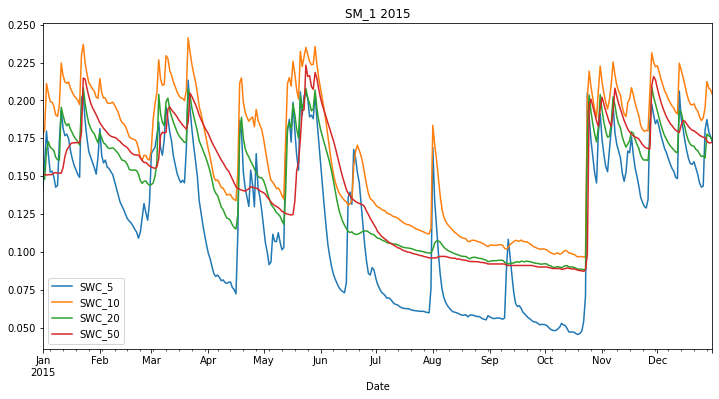

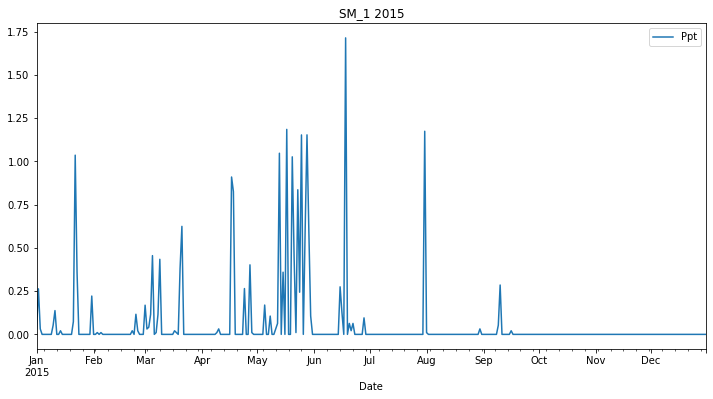

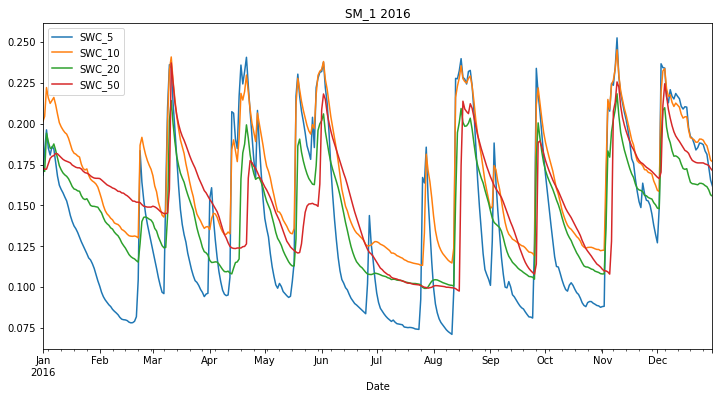

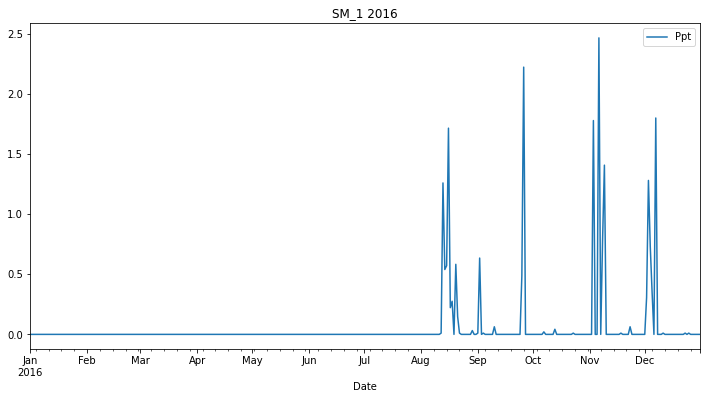

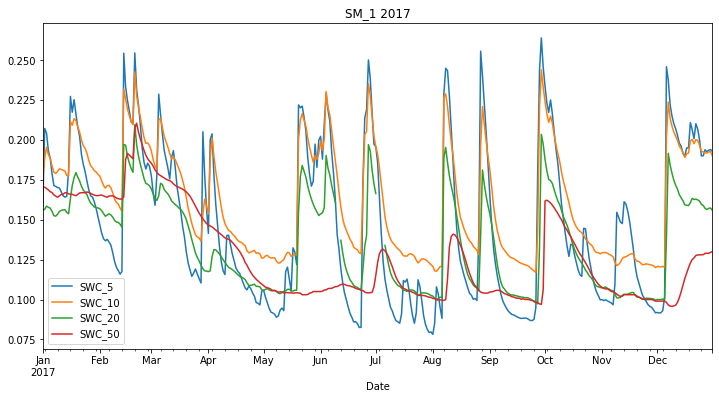

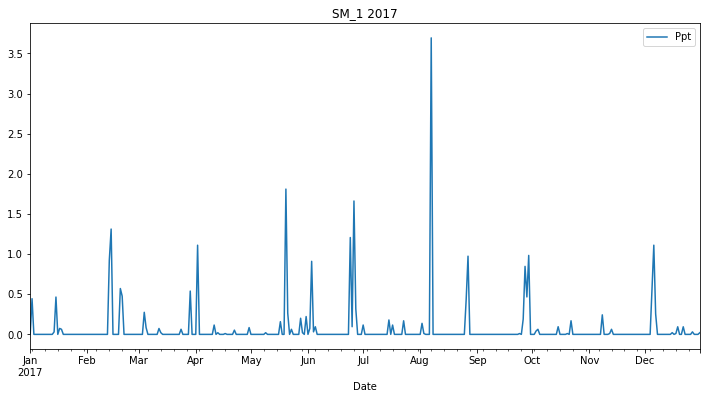

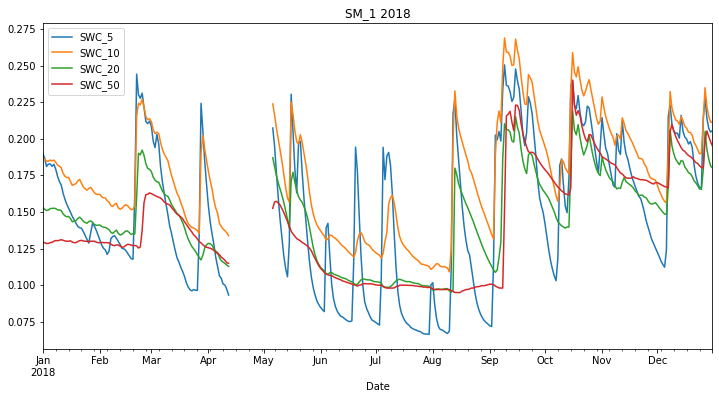

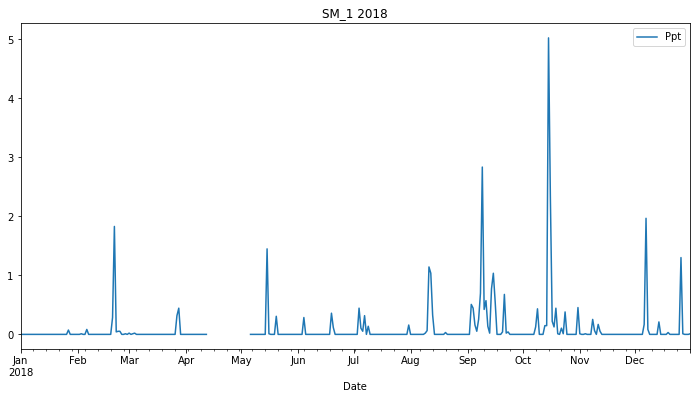

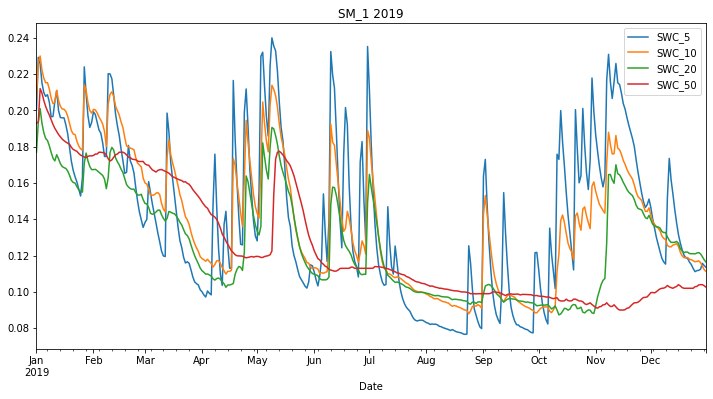

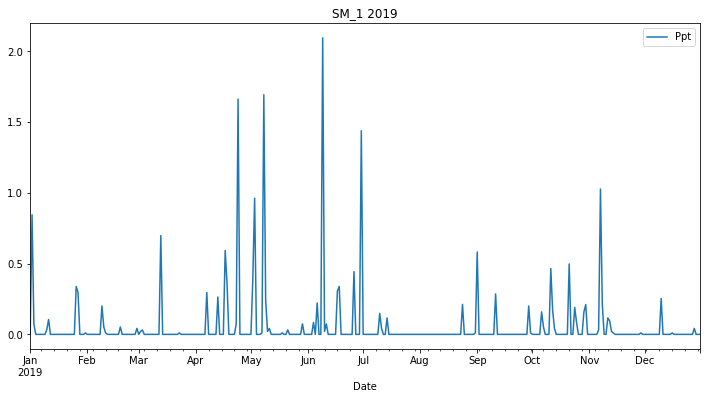

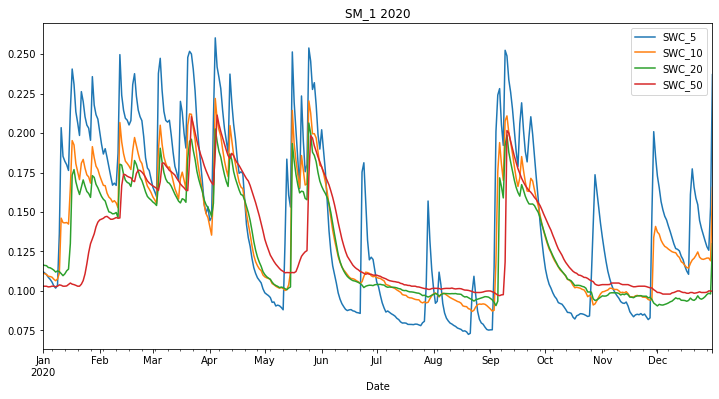

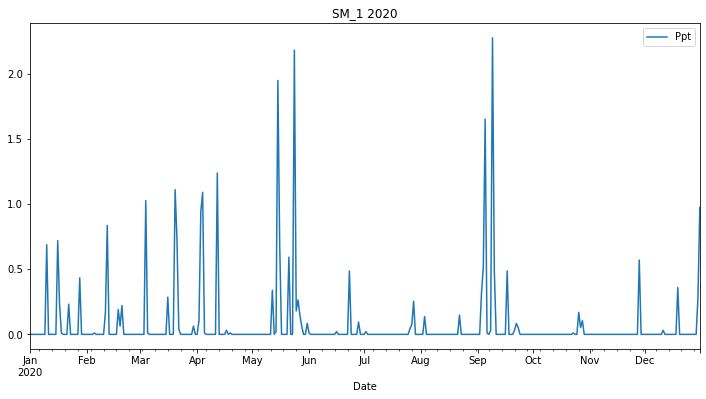

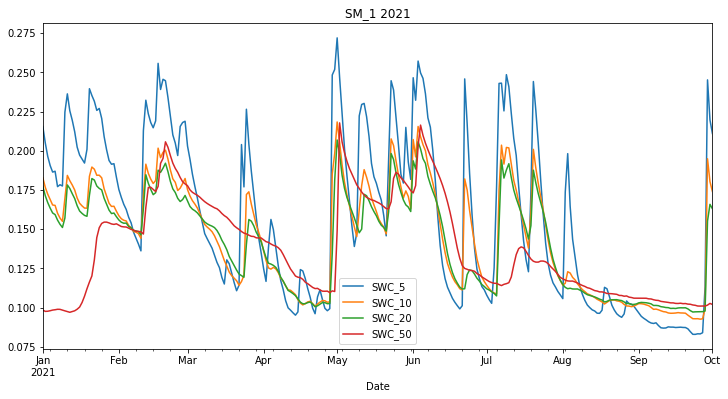

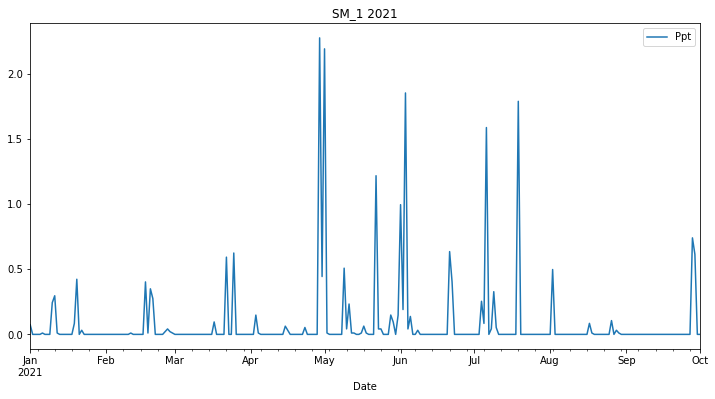

In [63]:
%matplotlib inline

years = [str(item) for item in range(2015, 2022)]

def plot_dataframe(df, title):
  for y in years:
    df.loc[y].resample('D').mean().plot(figsize=(12,6), y=["SWC_5", "SWC_10", "SWC_20", "SWC_50"], title=f"{title} {y}")
    df.loc[y].resample('D').mean().plot(figsize=(12,6), y=["Ppt"], title=f"{title} {y}")

df_sm_1 = DATAFRAMES["SM_1.dat"]
plot_dataframe(df_sm_1, "SM_1")
plt.show()

# Define imputation methods

In [64]:
# imputes missing data using mean of all past and future data for each feature
def fill_using_mean(df):
  df_mean = df.copy()

  for col in df.columns:
    col_mean = df[col].astype(np.float64).mean()
    df_mean = df_mean.assign(**{ col: df[col].fillna(col_mean) })
  
  return df_mean

# imputes missing data using median of all past and future data for each feature
def fill_using_median(df):
  df_median = df.copy()

  for col in df.columns:
    col_median = df[col].astype(np.float64).median()
    df_median = df_median.assign(**{ col: df[col].fillna(col_median) })
  
  return df_median

# imputes missing data using last available data point before a gap carried forward
def flll_using_last_observation_forward(df):
  df_last_observation = df.copy()

  for col in df.columns:
    df_last_observation = df_last_observation.assign(**{ col: df[col].fillna(method ='bfill') })
  
  return df_last_observation
  
# imputes missing data using first available data point after a gap carried backward
def flll_using_next_observation_backward(df):
  df_next_observation = df.copy()

  for col in df.columns:
    df_next_observation = df_next_observation.assign(**{ col: df[col].fillna(method ='ffill') })
  
  return df_next_observation 
  
# imputes missing data using linear function
def fill_using_linear_interpolation(df):
  df_linear = df.copy()

  for col in df.columns:
    df_linear = df_linear.assign(**{ col: df[col].fillna(df[col].interpolate(option='linear')) })
  
  return df_linear

# # imputes missing data using spline function
def fill_using_spline_interpolation(df):
  df_spline = df.copy()

  for col in df.columns:
    df_spline = df_spline.assign(**{ col: df[col].fillna(df[col].interpolate(option='spline')) })
  
  return df_spline

# different avg methods from:
# https://www.geeksforgeeks.org/how-to-calculate-moving-average-in-a-pandas-dataframe/

# imputes missing data using average of all data prior to gap for each feature
def fill_using_cumulative_moving_avg(df):
  df_rolling_avg = df.copy()

  for col in df.columns:
    df_rolling_avg = df_rolling_avg.assign(**{ col: df[col].fillna(df[col].expanding().mean()) })
  
  return df_rolling_avg

# imputes missing data using average of data in specific rolling window of time preceding missing data
def fill_using_30d_rolling_avg(df):
  window = 24 * 30 * 3 # 30 days
  df_rolling_avg = df.copy()

  for col in df.columns:
    df_rolling_avg = df_rolling_avg.assign(**{ col: df[col].fillna(df[col].rolling(window, min_periods=1).mean()) })
  
  return df_rolling_avg

# imputes missing data using exponential average of data in specific rolling window of time preceding missing data
# (places more weight toward more recent data points)
def fill_using_exponential_moving_avg(df):
  window = 24 * 30 * 3 # 30 days
  df_rolling_avg = df.copy()

  for col in df.columns:
    df_rolling_avg = df_rolling_avg.assign(**{ col: df[col].fillna(df[col].ewm(span=window).mean()) })
  
  return df_rolling_avg

# Fill missing SM_1 data with imputation methods

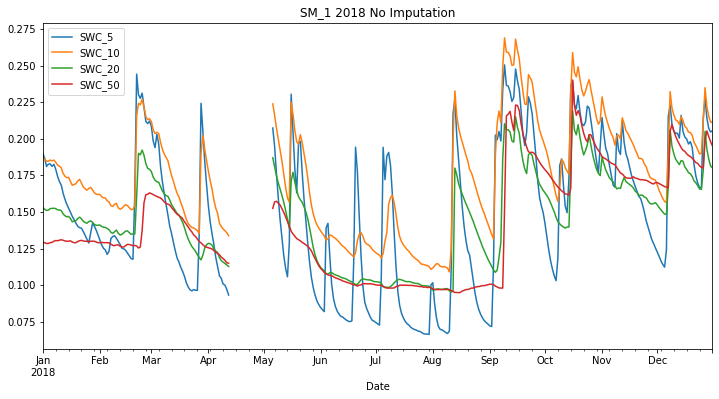

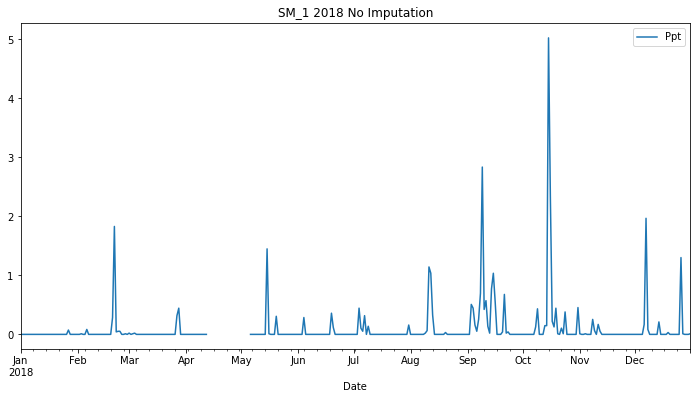

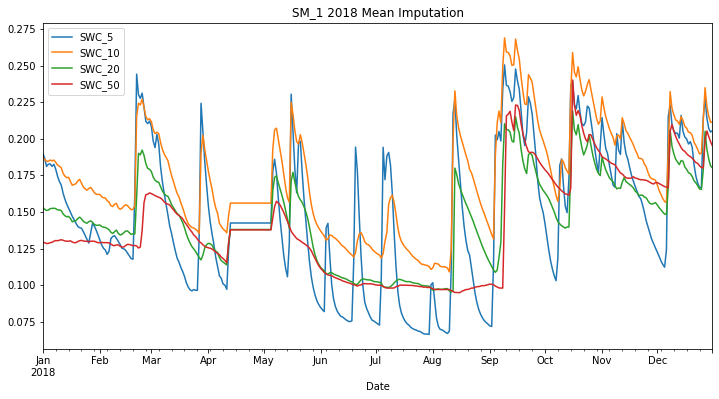

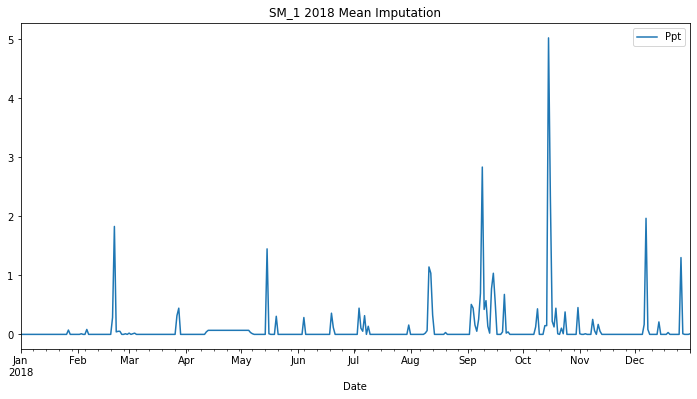

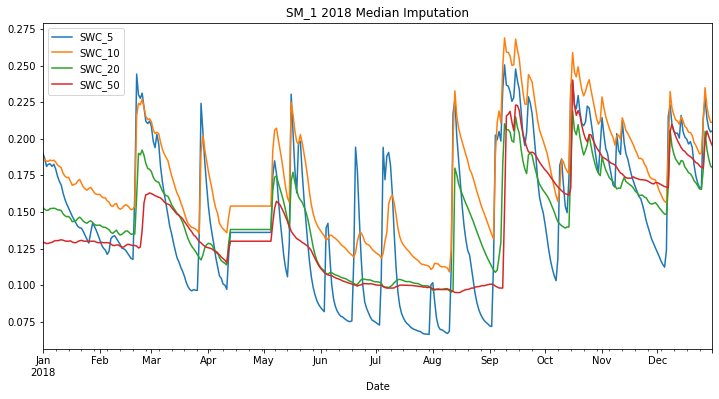

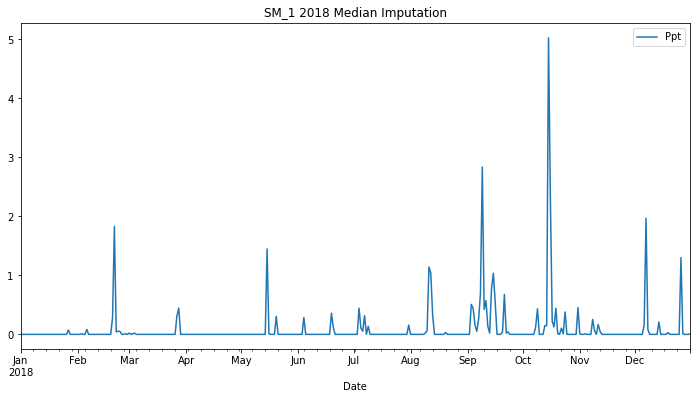

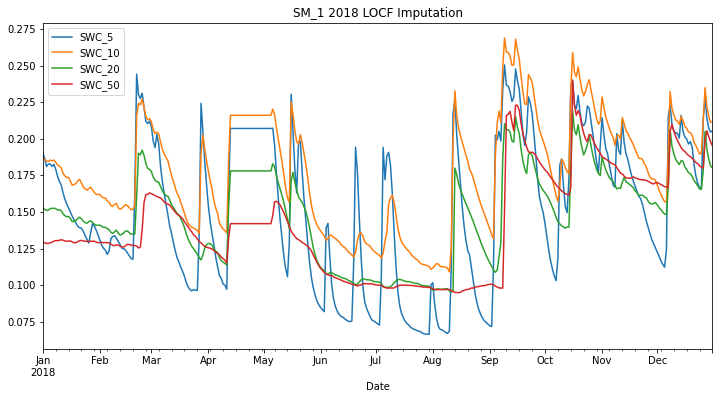

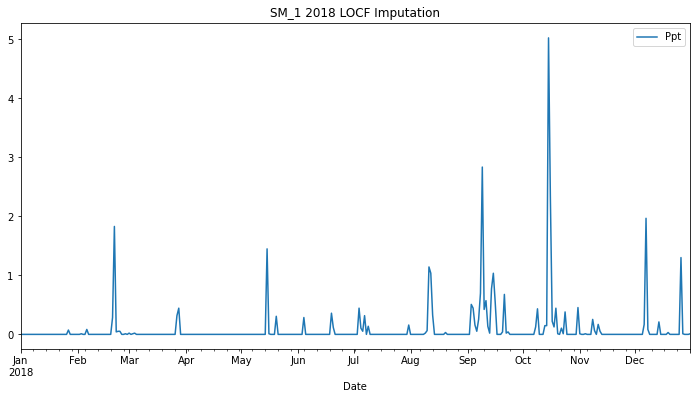

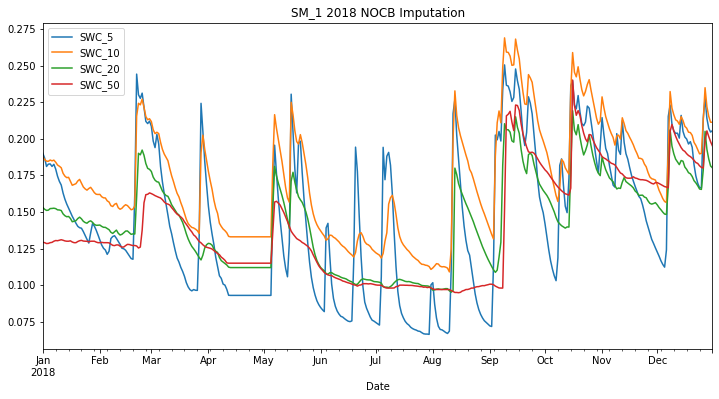

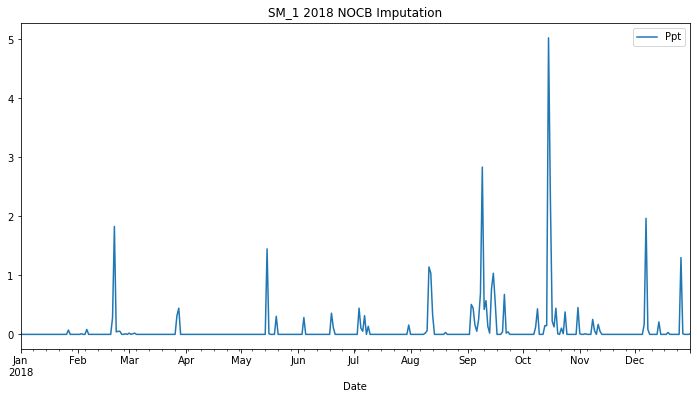

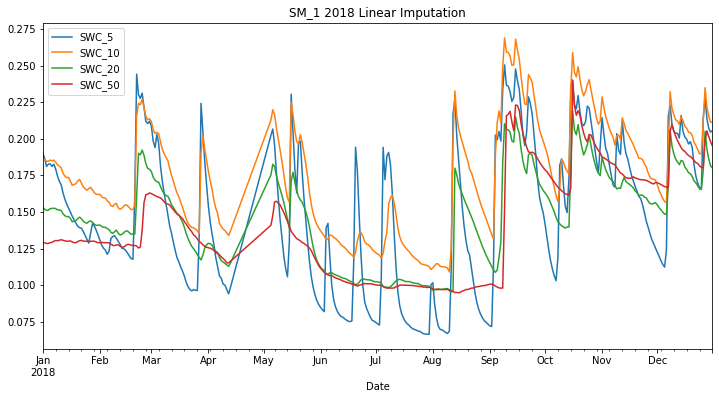

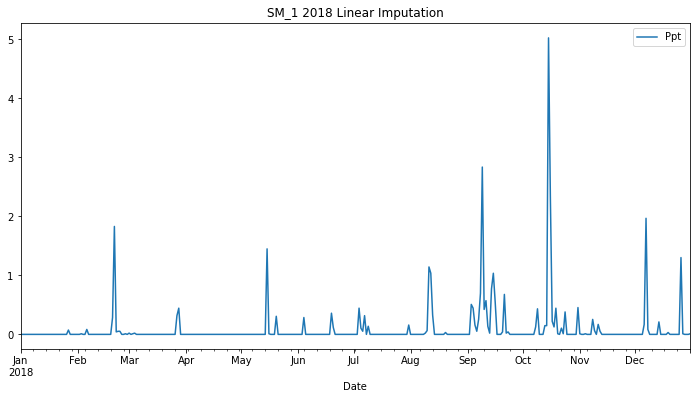

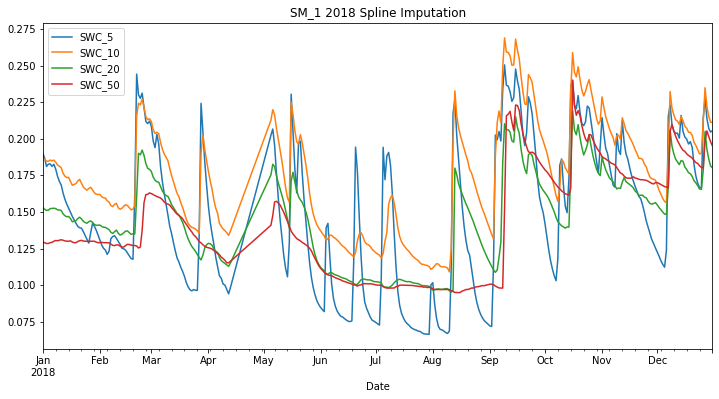

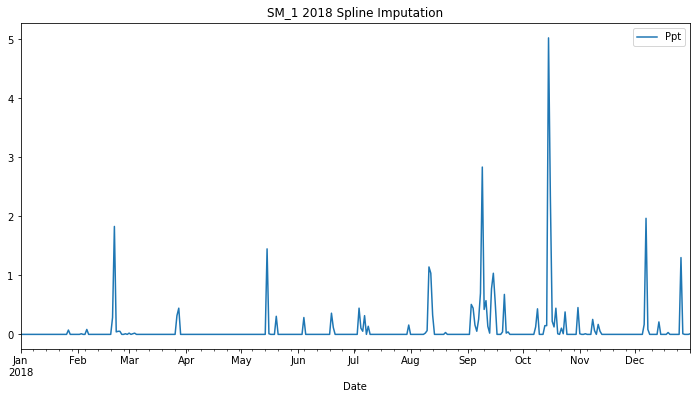

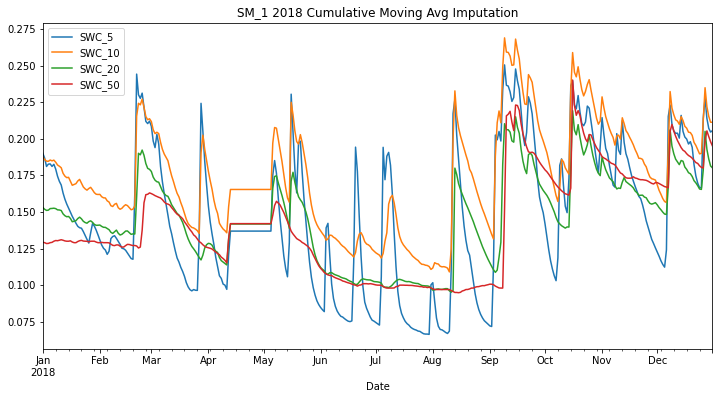

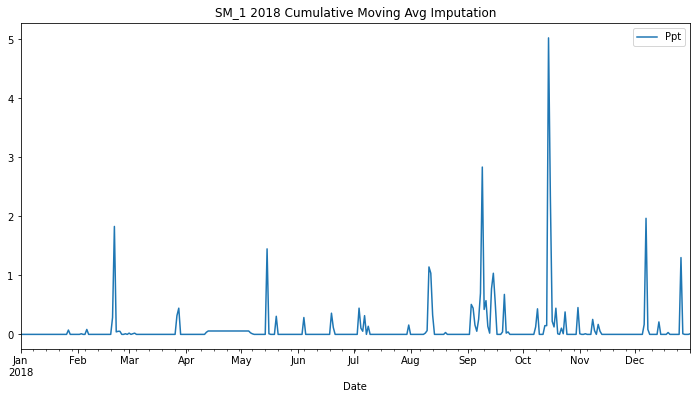

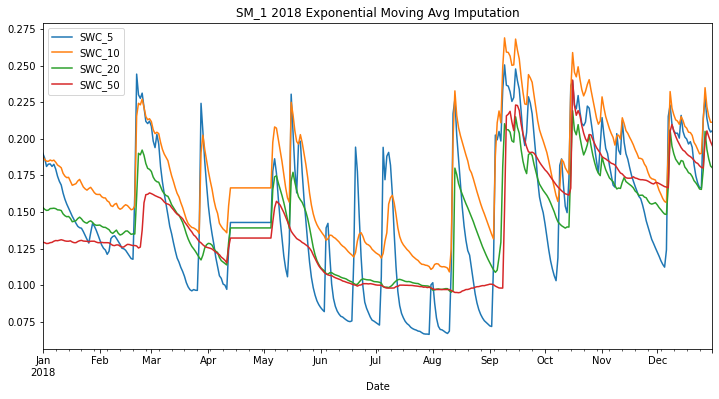

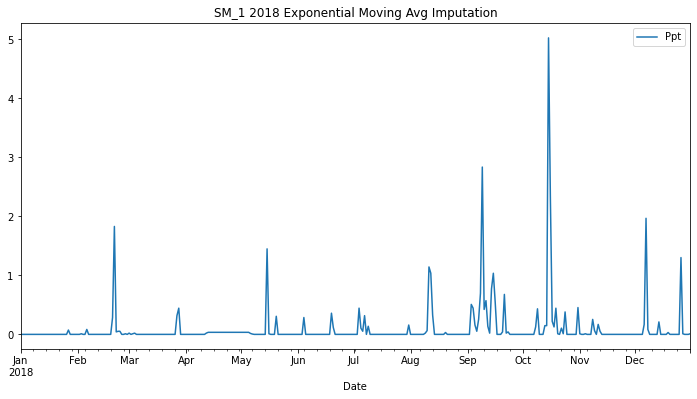

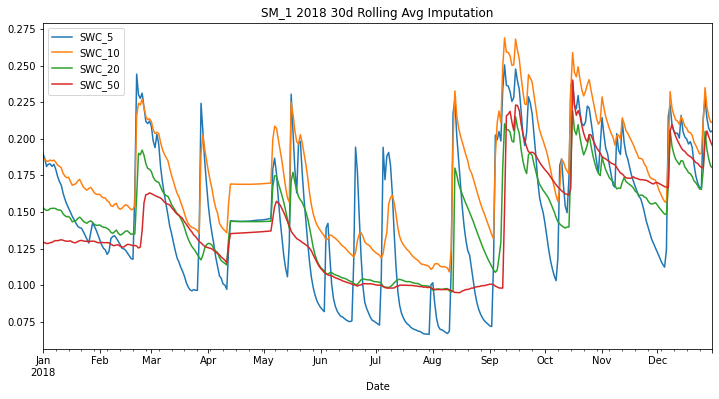

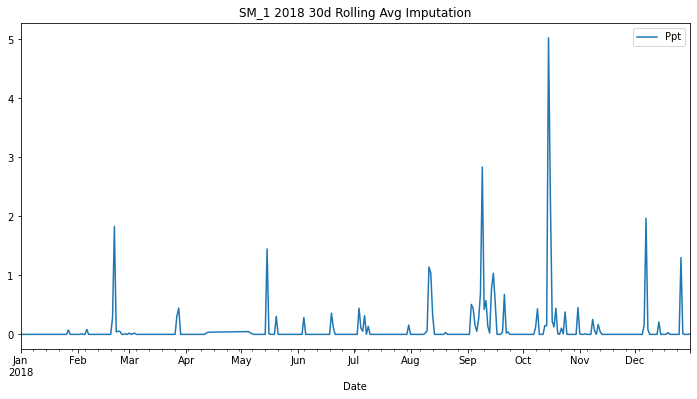

In [65]:
def plot_df(df, year, title):
  df.loc[year].resample('D').mean().plot(figsize=(12,6), y=["SWC_5", "SWC_10", "SWC_20", "SWC_50"], title=title)
  df.loc[year].resample('D').mean().plot(figsize=(12,6), y=["Ppt"], title=title)

year_to_visualize = '2018'
plot_df(df_sm_1, year_to_visualize, "SM_1 2018 No Imputation")

plot_df(fill_using_mean(df_sm_1), year_to_visualize, "SM_1 2018 Mean Imputation")
plot_df(fill_using_median(df_sm_1), year_to_visualize, "SM_1 2018 Median Imputation")

plot_df(flll_using_last_observation_forward(df_sm_1), year_to_visualize, "SM_1 2018 LOCF Imputation")
plot_df(flll_using_next_observation_backward(df_sm_1), year_to_visualize, "SM_1 2018 NOCB Imputation")

plot_df(fill_using_linear_interpolation(df_sm_1), year_to_visualize, "SM_1 2018 Linear Imputation")
plot_df(fill_using_spline_interpolation(df_sm_1), year_to_visualize, "SM_1 2018 Spline Imputation")

plot_df(fill_using_cumulative_moving_avg(df_sm_1), year_to_visualize, "SM_1 2018 Cumulative Moving Avg Imputation")
plot_df(fill_using_exponential_moving_avg(df_sm_1), year_to_visualize, "SM_1 2018 Exponential Moving Avg Imputation")
plot_df(fill_using_30d_rolling_avg(df_sm_1), year_to_visualize, "SM_1 2018 30d Rolling Avg Imputation")
plt.show()